# Review Score Prediction and Outlier Validation

## Overview

This notebook links the embedding and style metrics computed to the AI-generated review scores in `human-AI-proposal/data/reviews/ai_reviews/{condition}/ncems_criteria/ncems_reviews_20260416_122201.json`. and `human-AI-proposal/data/reviews/ai_reviews/{condition}/novelty/novelty_reviews_20260416_122206.json`

**Two primary goals:**
1. **Metric validation** — test whether computed metrics (semantic diversity metrics such as controid_dist, is_outlier, is_most_novel etc) correlate and predict review scores (either ncems_criteria or novelty).

2. **Outlier validation** — test whether proposals identified as most semantically unique (top-10% nearest-neighbor distance within all proposals or within literature embedding space) actually received higher scores on "Novelty & Significance" from NCEMS criteria or each novelty score criteria from novelty reviews.

**Review data structure:**
- 92 proposals × 3 AI evaluators (GPT, Gemini, Claude) x 2 types of reviews (ncems criteria or novelty) = 276 reviews 
- From NCEMS criteria: 7 scored criteria: Relevance to Emergent Phenomena, Novelty & Significance, Rigor of Approach, Scope & Timeline, Synthesis Focus, Data Identification, Open Science Commitment
- From NOVELTY criteria: new_question_topic_or_framing, new_theory_concept_method_dataset_or_design, unusual_combination_of_existing_ideas, beyond_state_of_the_art, credible_high_risk_high_gain, unique_knowledge_generation

In [1]:
import sys
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP and embeddings
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from scipy.spatial.distance import cdist
from tqdm import tqdm

# Statistics
from scipy import stats
from scipy.stats import mannwhitneyu
import itertools

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print(f"✓ Working directory: {os.getcwd()}")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

# Visualization: 2D Embedding Space with UMAP
# Install umap-learn if not already installed
try:
    import umap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn'])
    import umap

condition = 'rephrased/minimal'
# Ensure output directory exists
ALL_PROPOSALS_PATH = Path('../results/tables/rephrased/minimal/all_proposals.json')

NCEMS_REVIEWS_PATH  = Path('../data/reviews/ai_reviews/minimal/ncems_criteria/ncems_reviews_20260416_122201.json')
NOVELTY_REVIEWS_PATH = Path('../data/reviews/ai_reviews/minimal/novelty/novelty_reviews_20260416_122206.json')

RESULTS_DIR = Path('../results')
FIGURES_DIR = RESULTS_DIR / 'figures' / condition / 'metric-score'
TABLES_DIR = RESULTS_DIR / 'tables' / condition / 'metric-score'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

✓ Imports successful
✓ Working directory: /Users/eveyhuang/Documents/NICO/human-AI-proposal/baseline(minimal)-rephrased
✓ PyTorch version: 2.9.1
✓ CUDA available: False


In [2]:
# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-5': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}

## 0. Parse Review Files → Update `all_proposals.json`

Reads `ncems_reviews` and `novelty_reviews`, averages scores across the 3 AI evaluators for each proposal, and writes the averaged scores back into `all_proposals.json` under each proposal's `metrics` dict.

**NCEMS fields added:** `relevance_to_emergent_phenomena`, `novelty_and_significance`, `rigor_of_approach`, `scope_and_timeline`, `synthesis_focus`, `data_identification`, `open_science_commitment`, `review_score_mean`  
**Novelty fields added:** `new_question_topic_or_framing`, `new_theory_concept_method_dataset_or_design`, `unusual_combination_of_existing_ideas`, `beyond_state_of_the_art`, `credible_high_risk_high_gain`, `unique_knowledge_generation`, `novelty_score_mean`

In [3]:
from collections import defaultdict

# ── Mapping: NCEMS criterion display name → all_proposals.json field name ──
NCEMS_FIELD_MAP = {
    'Relevance to Emergent Phenomena': 'relevance_to_emergent_phenomena',
    'Novelty & Significance':          'novelty_and_significance',
    'Rigor of Approach':               'rigor_of_approach',
    'Scope & Timeline':                'scope_and_timeline',
    'Synthesis Focus':                 'synthesis_focus',
    'Data Identification':             'data_identification',
    'Open Science Commitment':         'open_science_commitment',
}

NOVELTY_FIELDS = [
    'new_question_topic_or_framing',
    'new_theory_concept_method_dataset_or_design',
    'unusual_combination_of_existing_ideas',
    'beyond_state_of_the_art',
    'credible_high_risk_high_gain',
    'unique_knowledge_generation',
]

# ── Load review files ──────────────────────────────────────────────────────
with open(NCEMS_REVIEWS_PATH) as f:
    ncems_data = json.load(f)
with open(NOVELTY_REVIEWS_PATH) as f:
    novelty_data = json.load(f)
with open(ALL_PROPOSALS_PATH) as f:
    proposals = json.load(f)

print(f"NCEMS reviews  : {len(ncems_data['reviews'])} (across {len(set(r['title'] for r in ncems_data['reviews']))} proposals)")
print(f"Novelty reviews: {len(novelty_data['reviews'])} (across {len(set(r['title'] for r in novelty_data['reviews']))} proposals)")
print(f"Proposals      : {len(proposals)}")

NCEMS reviews  : 276 (across 92 proposals)
Novelty reviews: 276 (across 92 proposals)
Proposals      : 92


In [4]:
# ── Build per-proposal score accumulators ──────────────────────────────────

# NCEMS: title → {field: [score, score, score]}
ncems_scores  = defaultdict(lambda: defaultdict(list))
ncems_overall = defaultdict(list)

for review in ncems_data['reviews']:
    title     = review['title']
    eval_data = review['evaluations'].get('evaluation', {})
    if not eval_data:
        continue
    for cat in eval_data.get('criteria_scores', []):
        for sub in cat.get('subcriteria', []):
            field = NCEMS_FIELD_MAP.get(sub['criterion'])
            if field:
                ncems_scores[title][field].append(sub['score'])
    overall = eval_data.get('overall_rating', {}).get('final_numeric_score')
    if overall is not None:
        ncems_overall[title].append(overall)

# Novelty: title → {field: [score, score, score]}
novelty_scores  = defaultdict(lambda: defaultdict(list))
novelty_overall = defaultdict(list)

for review in novelty_data['reviews']:
    title     = review['title']
    eval_data = review['evaluations']
    if not eval_data:
        continue
    for field in NOVELTY_FIELDS:
        entry = eval_data.get(field, {})
        if isinstance(entry, dict) and 'score' in entry:
            novelty_scores[title][field].append(entry['score'])
    overall = eval_data.get('overall_novelty_score')
    if overall is not None:
        novelty_overall[title].append(overall)

# ── Write averaged scores back into all_proposals.json ────────────────────
for prop in proposals:
    title = prop['title']
    m     = prop['metrics']

    # NCEMS criteria (mean across evaluators)
    for field in NCEMS_FIELD_MAP.values():
        scores = ncems_scores[title].get(field, [])
        m[field] = round(sum(scores) / len(scores), 4) if scores else None

    # NCEMS overall score
    ov = ncems_overall.get(title, [])
    m['review_score_mean'] = round(sum(ov) / len(ov), 4) if ov else None

    # Novelty criteria (mean across evaluators)
    for field in NOVELTY_FIELDS:
        scores = novelty_scores[title].get(field, [])
        m[field] = round(sum(scores) / len(scores), 4) if scores else None

    # Novelty overall score
    ov_nov = novelty_overall.get(title, [])
    m['novelty_score_mean'] = round(sum(ov_nov) / len(ov_nov), 4) if ov_nov else None

# ── Save ───────────────────────────────────────────────────────────────────
with open(ALL_PROPOSALS_PATH, 'w') as f:
    json.dump(proposals, f, indent=2)

print(f"Updated {len(proposals)} proposals and saved to {ALL_PROPOSALS_PATH}")

# Quick sanity check on first proposal
m0 = proposals[0]['metrics']
check_fields = ['relevance_to_emergent_phenomena', 'novelty_and_significance',
                'review_score_mean', 'new_question_topic_or_framing', 'novelty_score_mean']
print("\nSample (first proposal):")
for k in check_fields:
    print(f"  {k}: {m0.get(k)}")

Updated 92 proposals and saved to ../results/tables/rephrased/minimal/all_proposals.json

Sample (first proposal):
  relevance_to_emergent_phenomena: 5.0
  novelty_and_significance: 4.6667
  review_score_mean: 4.4333
  new_question_topic_or_framing: 4.0
  novelty_score_mean: 4.1667


## 1. Load Data and Build Unified DataFrame

`all_proposals.json` now contains averaged NCEMS criteria scores and novelty scores from the three AI evaluators. Here we flatten it into a single pandas DataFrame.

In [5]:
# Re-load the freshly updated file
with open(ALL_PROPOSALS_PATH) as f:
    proposals = json.load(f)

print(f"Loaded {len(proposals)} proposals")
print(f"Groups: {set(p['group'] for p in proposals)}")

Loaded 92 proposals
Groups: {'gemini-3-pro-preview', 'claude-opus-4-5', 'Human', 'gpt-5.2'}


In [6]:
# Flatten into a single DataFrame
rows = []
for p in proposals:
    row = {
        'title':  p['title'],
        'group':  p['group'],
        'is_ai':  p['is_ai'],
        'model':  p['model'],
        'cohort': p.get('cohort'),
    }
    row.update(p['metrics'])
    rows.append(row)

df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

DataFrame shape: (92, 52)

Columns: ['title', 'group', 'is_ai', 'model', 'cohort', 'centroid_dist', 'nn_dist', 'is_outlier', 'threshold', 'raw_novelty', 'novelty_z', 'novelty_ratio', 'is_most_novel_raw', 'is_most_novel_z', 'is_most_novel_ratio', 'n_words', 'n_chars', 'n_sents', 'avg_word_len', 'avg_sent_len_words', 'type_token_ratio', 'stopword_rate', 'hedge_rate', 'flesch_reading_ease', 'fk_grade_level', 'comma_per_1k_chars', 'semicolon_per_1k_chars', 'colon_per_1k_chars', 'dash_per_1k_chars', 'paren_per_1k_chars', 'quote_per_1k_chars', 'newline_per_1k_chars', 'bullet_per_1k_chars', 'data_identification', 'novelty_and_significance', 'open_science_commitment', 'relevance_to_emergent_phenomena', 'rigor_of_approach', 'scope_and_timeline', 'synthesis_focus', 'review_score_mean', 'pairwise_mean_dist', 'mi_centroid_dist', 'mi_nn_dist', 'mi_pairwise_mean_dist', 'new_question_topic_or_framing', 'new_theory_concept_method_dataset_or_design', 'unusual_combination_of_existing_ideas', 'beyond_sta

In [7]:
# Define column groups
SEMANTIC_METRICS = [
    'centroid_dist', 'nn_dist', 'pairwise_mean_dist',
    'mi_centroid_dist', 'mi_nn_dist', 'mi_pairwise_mean_dist',
    'raw_novelty', 'novelty_z', 'novelty_ratio',
]

STYLE_METRICS = [
    'n_words', 'n_chars', 'n_sents',
    'avg_word_len', 'avg_sent_len_words',
    'type_token_ratio', 'stopword_rate', 'hedge_rate',
    'flesch_reading_ease', 'fk_grade_level',
    'comma_per_1k_chars', 'semicolon_per_1k_chars',
    'newline_per_1k_chars', 'bullet_per_1k_chars',
]

NCEMS_SCORES = [
    'relevance_to_emergent_phenomena',
    'novelty_and_significance',
    'rigor_of_approach',
    'scope_and_timeline',
    'synthesis_focus',
    'data_identification',
    'open_science_commitment',
    'review_score_mean',
]

NOVELTY_SCORES = [
    'new_question_topic_or_framing',
    'new_theory_concept_method_dataset_or_design',
    'unusual_combination_of_existing_ideas',
    'beyond_state_of_the_art',
    'credible_high_risk_high_gain',
    'unique_knowledge_generation',
    'novelty_score_mean',
]

OUTLIER_FLAGS = ['is_outlier', 'is_most_novel_raw', 'is_most_novel_z', 'is_most_novel_ratio']

print("Column groups defined.")
print(f"  Semantic metrics : {len(SEMANTIC_METRICS)}")
print(f"  Style metrics    : {len(STYLE_METRICS)}")
print(f"  NCEMS scores     : {len(NCEMS_SCORES)}")
print(f"  Novelty scores   : {len(NOVELTY_SCORES)}")

# Preview NCEMS score distributions
df[NCEMS_SCORES].describe().round(3)

Column groups defined.
  Semantic metrics : 9
  Style metrics    : 14
  NCEMS scores     : 8
  Novelty scores   : 7


,relevance_to_emergent_phenomena,novelty_and_significance,rigor_of_approach,scope_and_timeline,synthesis_focus,data_identification,open_science_commitment,review_score_mean
count,92.000,92.000,92.000,92.000,92.000,92.000,92.000,92.000
mean,4.688,4.283,3.775,3.062,4.851,3.554,4.152,3.936
std,0.728,0.184,0.411,0.335,0.462,0.562,0.680,0.361
min,1.333,3.333,2.333,2.333,2.333,2.333,1.667,2.633
25%,5.000,4.333,3.333,2.917,5.000,3.000,4.000,3.825
50%,5.000,4.333,3.667,3.000,5.000,3.333,4.333,3.933
75%,5.000,4.333,4.083,3.333,5.000,4.000,4.667,4.242
max,5.000,4.667,4.333,3.667,5.000,4.667,5.000,4.433


In [8]:
df[NOVELTY_SCORES].describe().round(3)

,new_question_topic_or_framing,new_theory_concept_method_dataset_or_design,unusual_combination_of_existing_ideas,beyond_state_of_the_art,credible_high_risk_high_gain,unique_knowledge_generation,novelty_score_mean
count,92.000,92.000,92.000,92.000,92.000,92.000,92.000
mean,3.685,3.384,4.348,3.538,3.549,4.094,3.704
std,0.474,0.480,0.447,0.437,0.351,0.330,0.358
min,2.667,2.000,2.667,2.333,2.000,3.000,2.433
25%,3.333,3.333,4.000,3.333,3.625,4.000,3.550
50%,3.667,3.333,4.333,3.667,3.667,4.000,3.733
75%,4.000,3.667,4.667,3.667,3.667,4.333,3.908
max,4.500,4.333,5.000,4.500,4.000,4.500,4.400


In [9]:
# Score distribution by group
print("NCEMS review_score_mean by group:")
print(df.groupby('group')['review_score_mean'].agg(['count', 'mean', 'std']).round(3))
print("\nNovelty score mean by group:")
print(df.groupby('group')['novelty_score_mean'].agg(['count', 'mean', 'std']).round(3))

NCEMS review_score_mean by group:
                      count   mean    std
group                                    
Human                    23  3.586  0.465
claude-opus-4-5          23  4.009  0.135
gemini-3-pro-preview     23  3.832  0.069
gpt-5.2                  23  4.317  0.055

Novelty score mean by group:
                      count   mean    std
group                                    
Human                    23  3.764  0.266
claude-opus-4-5          23  3.403  0.352
gemini-3-pro-preview     23  3.657  0.301
gpt-5.2                  23  3.993  0.237


## 2. Correlation: Semantic Metrics vs Review Scores

We compute Spearman rank correlations (robust to non-normality and outliers) between each semantic/style metric and each review score criterion.

In [10]:
def compute_corr_matrix(df, metrics, scores, method='spearman'):
    """Return a (metrics x scores) DataFrame of correlation coefficients."""
    rows = []
    for m in metrics:
        row = {}
        for s in scores:
            subset = df[[m, s]].dropna()
            if len(subset) < 5:
                row[s] = np.nan
            else:
                fn = stats.spearmanr if method == 'spearman' else stats.pearsonr
                r, _ = fn(subset[m], subset[s])
                row[s] = r
        rows.append(row)
    return pd.DataFrame(rows, index=metrics)

def compute_pval_matrix(df, metrics, scores, method='spearman'):
    """Return a (metrics x scores) DataFrame of p-values."""
    rows = []
    for m in metrics:
        row = {}
        for s in scores:
            subset = df[[m, s]].dropna()
            if len(subset) < 5:
                row[s] = np.nan
            else:
                fn = stats.spearmanr if method == 'spearman' else stats.pearsonr
                _, p = fn(subset[m], subset[s])
                row[s] = p
        rows.append(row)
    return pd.DataFrame(rows, index=metrics)

print("Helper functions defined.")

Helper functions defined.


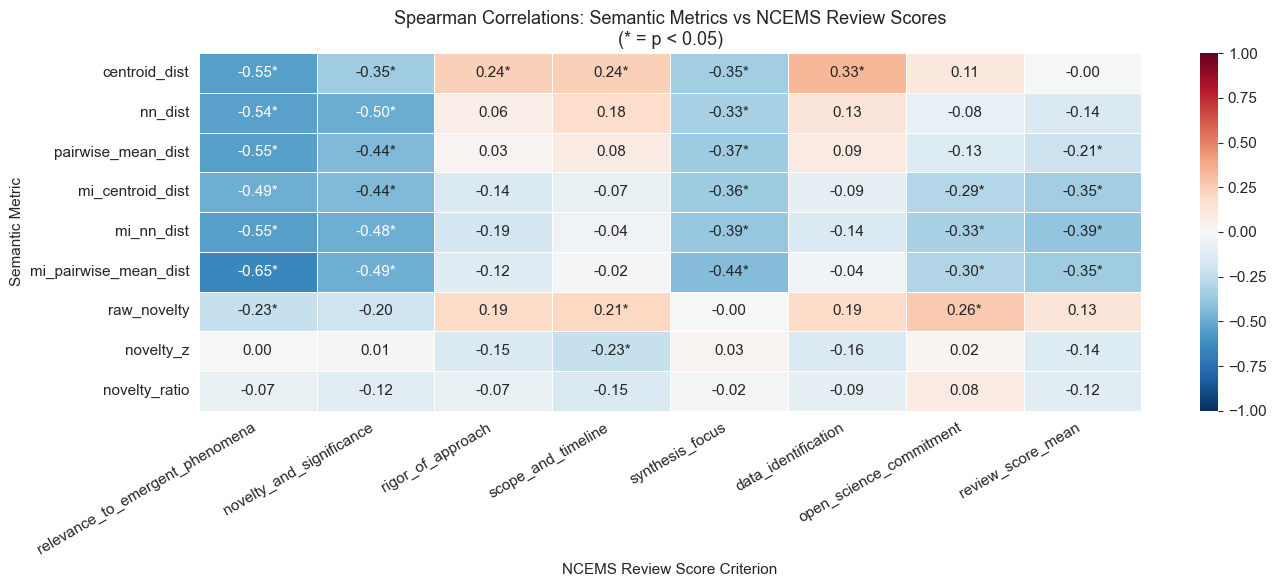

                       relevance_to_emergent_phenomena  \
centroid_dist                                   -0.548   
nn_dist                                         -0.541   
pairwise_mean_dist                              -0.548   
mi_centroid_dist                                -0.489   
mi_nn_dist                                      -0.554   
mi_pairwise_mean_dist                           -0.650   
raw_novelty                                     -0.228   
novelty_z                                        0.004   
novelty_ratio                                   -0.071   

                       novelty_and_significance  rigor_of_approach  \
centroid_dist                            -0.353              0.240   
nn_dist                                  -0.498              0.063   
pairwise_mean_dist                       -0.439              0.030   
mi_centroid_dist                         -0.438             -0.144   
mi_nn_dist                               -0.485             -0.186   

In [11]:
# --- Semantic metrics vs NCEMS scores ---
corr_sem_ncems = compute_corr_matrix(df, SEMANTIC_METRICS, NCEMS_SCORES)
pval_sem_ncems = compute_pval_matrix(df, SEMANTIC_METRICS, NCEMS_SCORES)

fig, ax = plt.subplots(figsize=(14, 6))

annot = corr_sem_ncems.round(2).astype(str)
for m in SEMANTIC_METRICS:
    for s in NCEMS_SCORES:
        r = corr_sem_ncems.loc[m, s]
        p = pval_sem_ncems.loc[m, s]
        annot.loc[m, s] = f"{r:.2f}{'*' if p < 0.05 else ''}"

sns.heatmap(
    corr_sem_ncems, annot=annot, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlations: Semantic Metrics vs NCEMS Review Scores\n(* = p < 0.05)', fontsize=13)
ax.set_xlabel('NCEMS Review Score Criterion')
ax.set_ylabel('Semantic Metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_semantic_ncems.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_sem_ncems.round(3))

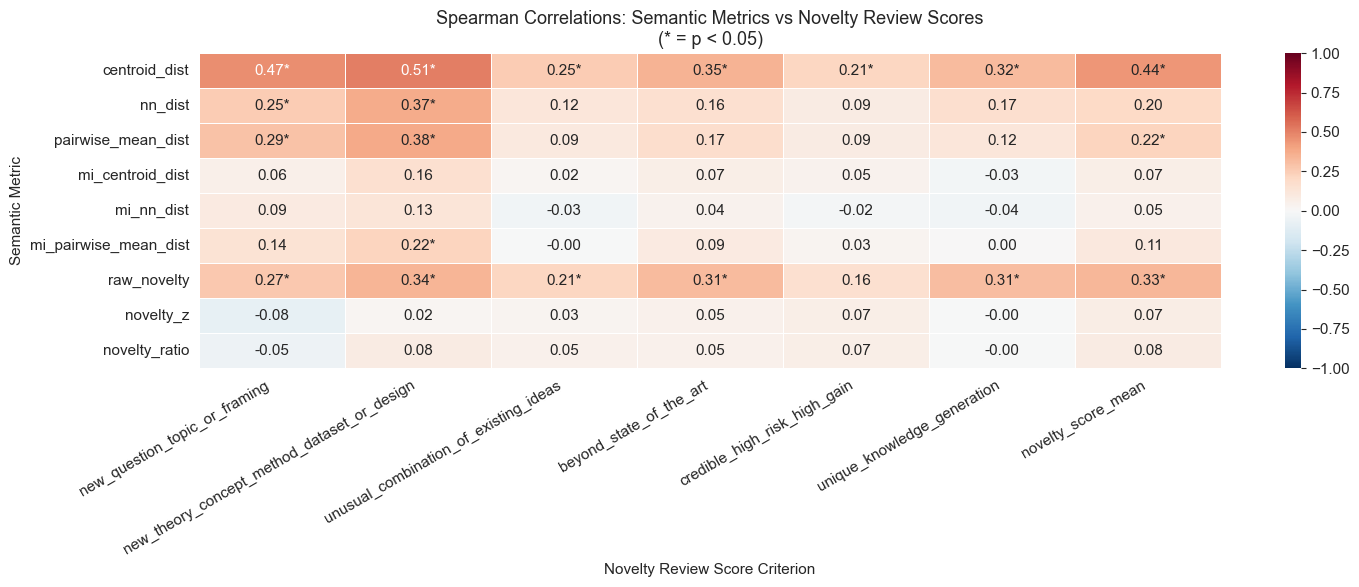

                       new_question_topic_or_framing  \
centroid_dist                                  0.467   
nn_dist                                        0.253   
pairwise_mean_dist                             0.293   
mi_centroid_dist                               0.058   
mi_nn_dist                                     0.089   
mi_pairwise_mean_dist                          0.143   
raw_novelty                                    0.267   
novelty_z                                     -0.078   
novelty_ratio                                 -0.047   

                       new_theory_concept_method_dataset_or_design  \
centroid_dist                                                0.509   
nn_dist                                                      0.373   
pairwise_mean_dist                                           0.381   
mi_centroid_dist                                             0.160   
mi_nn_dist                                                   0.130   
mi_pairwise_mean_di

In [12]:
# --- Semantic metrics vs Novelty scores ---
corr_sem_nov = compute_corr_matrix(df, SEMANTIC_METRICS, NOVELTY_SCORES)
pval_sem_nov = compute_pval_matrix(df, SEMANTIC_METRICS, NOVELTY_SCORES)

fig, ax = plt.subplots(figsize=(15, 6))

annot2 = corr_sem_nov.round(2).astype(str)
for m in SEMANTIC_METRICS:
    for s in NOVELTY_SCORES:
        r = corr_sem_nov.loc[m, s]
        p = pval_sem_nov.loc[m, s]
        annot2.loc[m, s] = f"{r:.2f}{'*' if p < 0.05 else ''}"

sns.heatmap(
    corr_sem_nov, annot=annot2, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlations: Semantic Metrics vs Novelty Review Scores\n(* = p < 0.05)', fontsize=13)
ax.set_xlabel('Novelty Review Score Criterion')
ax.set_ylabel('Semantic Metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_semantic_novelty.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_sem_nov.round(3))

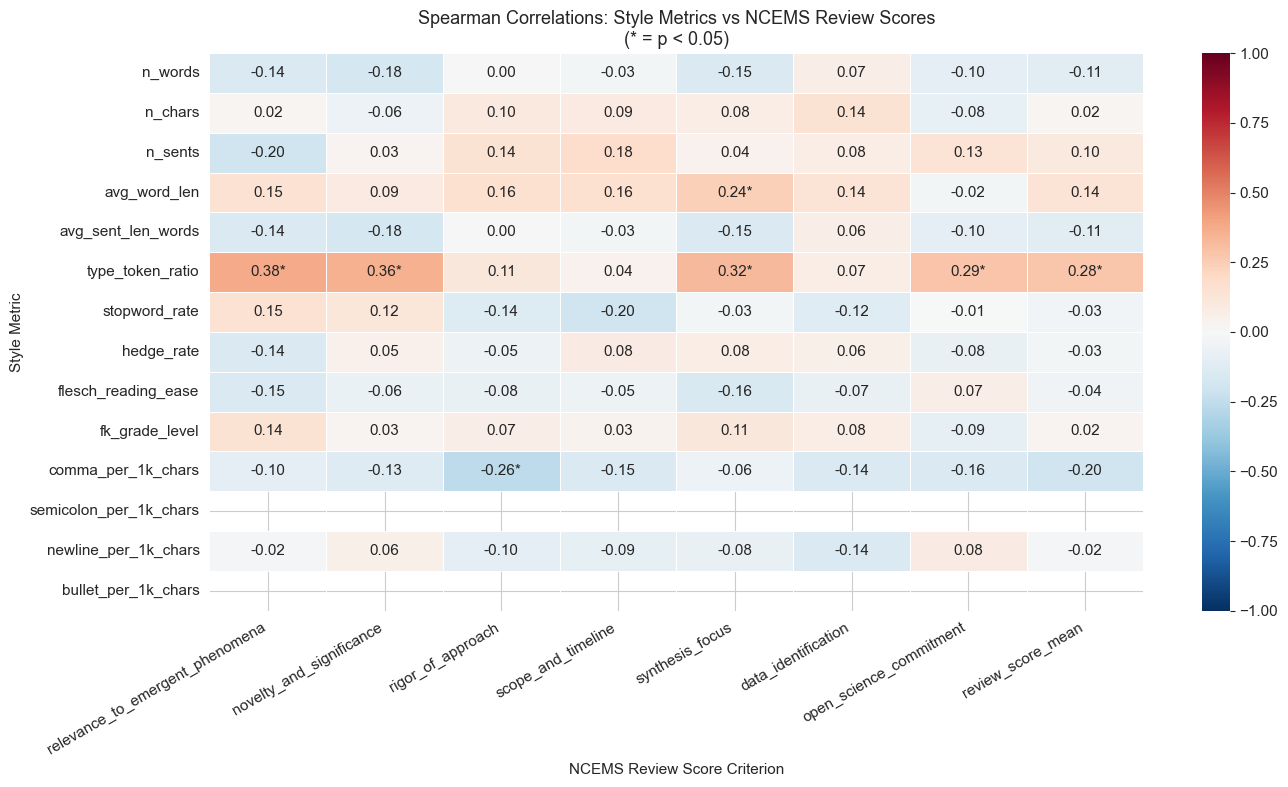

In [13]:
# --- Style metrics vs NCEMS scores ---
corr_sty_ncems = compute_corr_matrix(df, STYLE_METRICS, NCEMS_SCORES)
pval_sty_ncems = compute_pval_matrix(df, STYLE_METRICS, NCEMS_SCORES)

fig, ax = plt.subplots(figsize=(14, 8))

annot3 = corr_sty_ncems.round(2).astype(str)
for m in STYLE_METRICS:
    for s in NCEMS_SCORES:
        r = corr_sty_ncems.loc[m, s]
        p = pval_sty_ncems.loc[m, s]
        annot3.loc[m, s] = f"{r:.2f}{'*' if p < 0.05 else ''}"

sns.heatmap(
    corr_sty_ncems, annot=annot3, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlations: Style Metrics vs NCEMS Review Scores\n(* = p < 0.05)', fontsize=13)
ax.set_xlabel('NCEMS Review Score Criterion')
ax.set_ylabel('Style Metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_style_ncems.png', dpi=150, bbox_inches='tight')
plt.show()

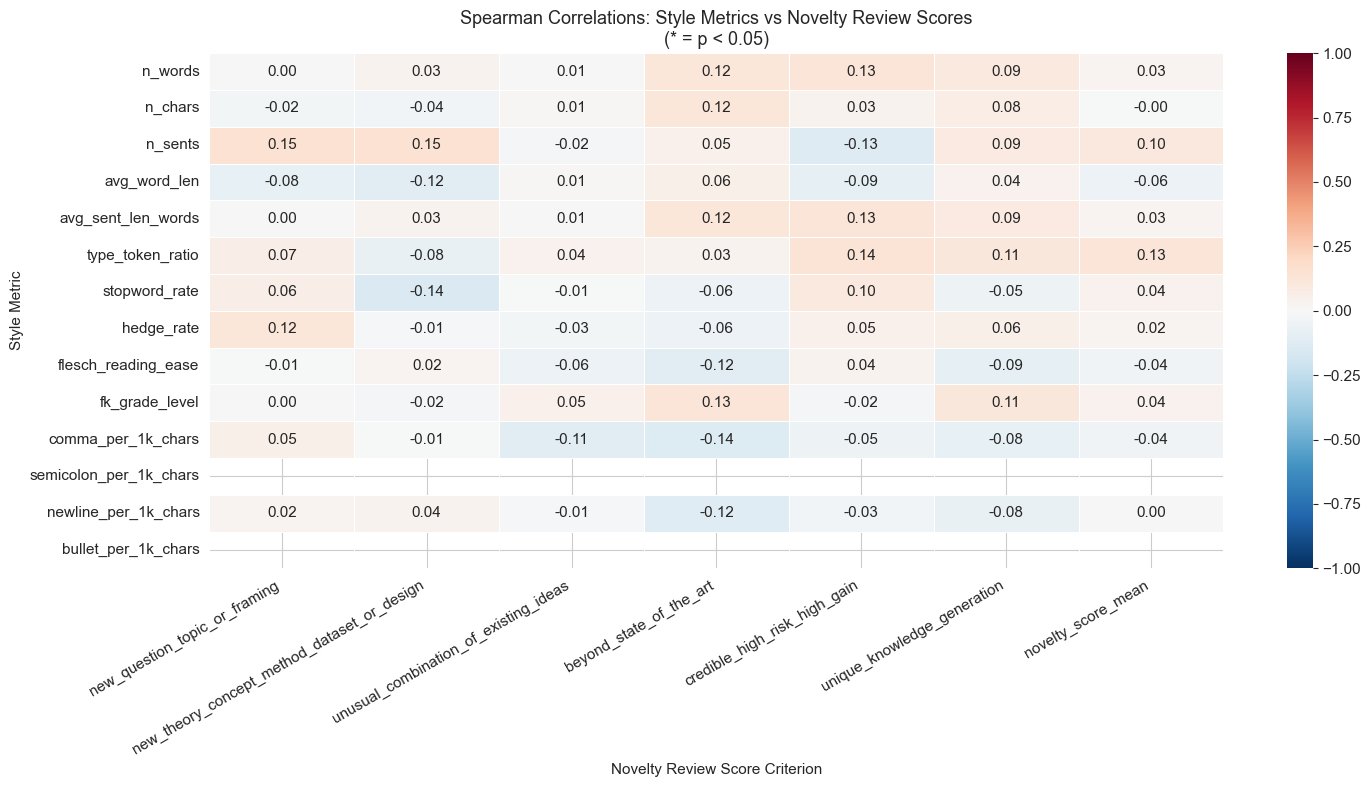

                        new_question_topic_or_framing  \
n_words                                         0.004   
n_chars                                        -0.025   
n_sents                                         0.152   
avg_word_len                                   -0.079   
avg_sent_len_words                              0.001   
type_token_ratio                                0.068   
stopword_rate                                   0.064   
hedge_rate                                      0.123   
flesch_reading_ease                            -0.006   
fk_grade_level                                  0.004   
comma_per_1k_chars                              0.055   
semicolon_per_1k_chars                            NaN   
newline_per_1k_chars                            0.025   
bullet_per_1k_chars                               NaN   

                        new_theory_concept_method_dataset_or_design  \
n_words                                                       0.034   
n_

In [22]:
# --- Style metrics vs Novelty scores ---
corr_sty_nov = compute_corr_matrix(df, STYLE_METRICS, NOVELTY_SCORES)
pval_sty_nov = compute_pval_matrix(df, STYLE_METRICS, NOVELTY_SCORES)

fig, ax = plt.subplots(figsize=(15, 8))

annot4 = corr_sty_nov.round(2).astype(str)
for m in STYLE_METRICS:
    for s in NOVELTY_SCORES:
        r = corr_sty_nov.loc[m, s]
        p = pval_sty_nov.loc[m, s]
        annot4.loc[m, s] = f"{r:.2f}{'*' if p < 0.05 else ''}"

sns.heatmap(
    corr_sty_nov, annot=annot4, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlations: Style Metrics vs Novelty Review Scores\n(* = p < 0.05)', fontsize=13)
ax.set_xlabel('Novelty Review Score Criterion')
ax.set_ylabel('Style Metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_style_novelty.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_sty_nov.round(3))

## 3. Strongest Correlations Summary

Report the top metric–score pairs by absolute Spearman r, with p-values.

In [14]:
def top_correlations(corr_df, pval_df, n=15, label=''):
    records = []
    for metric in corr_df.index:
        for score in corr_df.columns:
            r = corr_df.loc[metric, score]
            p = pval_df.loc[metric, score]
            if not np.isnan(r):
                records.append({'metric': metric, 'score': score, 'spearman_r': r, 'p_value': p})
    result = (
        pd.DataFrame(records)
        .sort_values('spearman_r', key=abs, ascending=False)
        .head(n)
    )
    result['sig'] = result['p_value'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    )
    print(f"\nTop {n} correlations — {label}")
    return result.reset_index(drop=True)

top_sem_ncems = top_correlations(corr_sem_ncems, pval_sem_ncems, n=15, label='Semantic vs NCEMS')
display(top_sem_ncems.round(4))

top_sem_nov = top_correlations(corr_sem_nov, pval_sem_nov, n=15, label='Semantic vs Novelty')
display(top_sem_nov.round(4))


Top 15 correlations — Semantic vs NCEMS


,metric,score,spearman_r,p_value,sig
0,mi_pairwise_mean_dist,relevance_to_emergent_phenomena,-0.6496,0.0000,***
1,mi_nn_dist,relevance_to_emergent_phenomena,-0.5544,0.0000,***
2,pairwise_mean_dist,relevance_to_emergent_phenomena,-0.5479,0.0000,***
3,centroid_dist,relevance_to_emergent_phenomena,-0.5478,0.0000,***
4,nn_dist,relevance_to_emergent_phenomena,-0.5410,0.0000,***
5,nn_dist,novelty_and_significance,-0.4981,0.0000,***
6,mi_centroid_dist,relevance_to_emergent_phenomena,-0.4892,0.0000,***
7,mi_pairwise_mean_dist,novelty_and_significance,-0.4863,0.0000,***
8,mi_nn_dist,novelty_and_significance,-0.4849,0.0000,***
9,pairwise_mean_dist,novelty_and_significance,-0.4392,0.0000,***



Top 15 correlations — Semantic vs Novelty


,metric,score,spearman_r,p_value,sig
0,centroid_dist,new_theory_concept_method_dataset_or_design,0.5093,0.0000,***
1,centroid_dist,new_question_topic_or_framing,0.4668,0.0000,***
2,centroid_dist,novelty_score_mean,0.4383,0.0000,***
3,pairwise_mean_dist,new_theory_concept_method_dataset_or_design,0.3809,0.0002,***
4,nn_dist,new_theory_concept_method_dataset_or_design,0.3734,0.0002,***
5,centroid_dist,beyond_state_of_the_art,0.3477,0.0007,***
6,raw_novelty,new_theory_concept_method_dataset_or_design,0.3378,0.0010,***
7,raw_novelty,novelty_score_mean,0.3289,0.0014,**
8,centroid_dist,unique_knowledge_generation,0.3203,0.0019,**
9,raw_novelty,beyond_state_of_the_art,0.3131,0.0024,**


## 4. Outlier Validation: Do Semantically Unique Proposals Score Higher?

We test whether proposals flagged as outliers (`is_outlier`, `is_most_novel_raw`, etc.) receive significantly higher review scores using Mann-Whitney U tests.

In [15]:
def outlier_score_comparison(df, flag_col, score_cols, title=''):
    """Mann-Whitney U test comparing flagged vs non-flagged proposals."""
    df_sub      = df.dropna(subset=[flag_col])
    flagged     = df_sub[df_sub[flag_col] == True]
    not_flagged = df_sub[df_sub[flag_col] == False]
    print(f"\n{title}")
    print(f"  Flagged: {len(flagged)} | Not flagged: {len(not_flagged)}")

    results = []
    for s in score_cols:
        x = flagged[s].dropna()
        y = not_flagged[s].dropna()
        if len(x) < 2 or len(y) < 2:
            continue
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
        results.append({
            'score':            s,
            'flagged_mean':     x.mean(),
            'not_flagged_mean': y.mean(),
            'diff':             x.mean() - y.mean(),
            'U':                stat,
            'p_value':          p,
            'sig':              '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')),
        })
    return pd.DataFrame(results).sort_values('p_value')


# NCEMS scores
print("=" * 60)
print("NCEMS Review Scores")
for flag in OUTLIER_FLAGS:
    res = outlier_score_comparison(df, flag, NCEMS_SCORES, title=f'Flag: {flag}')
    display(res.round(4))

print("\n" + "=" * 60)
print("Novelty Review Scores")
for flag in OUTLIER_FLAGS:
    res = outlier_score_comparison(df, flag, NOVELTY_SCORES, title=f'Flag: {flag}')
    display(res.round(4))

NCEMS Review Scores

Flag: is_outlier
  Flagged: 10 | Not flagged: 82


,score,flagged_mean,not_flagged_mean,diff,U,p_value,sig
0,relevance_to_emergent_phenomena,3.6333,4.8171,-1.1838,171.5,0.0000,***
1,novelty_and_significance,4.0333,4.3130,-0.2797,223.0,0.0001,***
4,synthesis_focus,4.5667,4.8862,-0.3195,336.5,0.1427,
3,scope_and_timeline,3.1666,3.0488,0.1179,517.5,0.1566,
7,review_score_mean,3.7667,3.9565,-0.1898,325.5,0.2901,
5,data_identification,3.6000,3.5488,0.0512,438.5,0.7172,
6,open_science_commitment,3.9667,4.1748,-0.2081,386.5,0.7610,
2,rigor_of_approach,3.7000,3.7845,-0.0845,408.0,0.9844,



Flag: is_most_novel_raw
  Flagged: 10 | Not flagged: 82


,score,flagged_mean,not_flagged_mean,diff,U,p_value,sig
1,novelty_and_significance,4.0333,4.3130,-0.2797,223.0,0.0001,***
0,relevance_to_emergent_phenomena,3.7667,4.8008,-1.0342,218.5,0.0011,**
7,review_score_mean,3.7000,3.9646,-0.2646,255.5,0.0524,
4,synthesis_focus,4.5667,4.8862,-0.3195,336.5,0.1427,
2,rigor_of_approach,3.5667,3.8008,-0.2341,323.0,0.2599,
6,open_science_commitment,3.9333,4.1789,-0.2455,354.0,0.4629,
5,data_identification,3.4667,3.5650,-0.0984,374.0,0.6460,
3,scope_and_timeline,3.0000,3.0691,-0.0691,388.5,0.7810,



Flag: is_most_novel_z
  Flagged: 10 | Not flagged: 82


...

,score,flagged_mean,not_flagged_mean,diff,U,p_value,sig
1,new_theory_concept_method_dataset_or_design,3.7000,3.3455,0.3545,566.5,0.0398,*
2,unusual_combination_of_existing_ideas,4.2667,4.3577,-0.0911,316.0,0.2241,
5,unique_knowledge_generation,3.9833,4.1077,-0.1244,364.0,0.5412,
0,new_question_topic_or_framing,3.7167,3.6809,0.0358,437.0,0.7336,
4,credible_high_risk_high_gain,3.5334,3.5508,-0.0175,387.5,0.7473,
3,beyond_state_of_the_art,3.5500,3.5366,0.0134,386.5,0.7656,
6,novelty_score_mean,3.7767,3.6955,0.0811,432.5,0.7821,



Flag: is_most_novel_z
  Flagged: 10 | Not flagged: 82


,score,flagged_mean,not_flagged_mean,diff,U,p_value,sig
4,credible_high_risk_high_gain,3.3333,3.5752,-0.2419,233.5,0.0099,**
6,novelty_score_mean,3.5567,3.7224,-0.1657,258.0,0.0568,
3,beyond_state_of_the_art,3.3333,3.5630,-0.2297,270.5,0.0716,
0,new_question_topic_or_framing,3.4667,3.7114,-0.2447,279.5,0.0950,
5,unique_knowledge_generation,3.9667,4.1097,-0.1431,294.0,0.1209,
2,unusual_combination_of_existing_ideas,4.2333,4.3618,-0.1284,313.5,0.2119,
1,new_theory_concept_method_dataset_or_design,3.4333,3.3780,0.0553,368.5,0.5889,



Flag: is_most_novel_ratio
  Flagged: 10 | Not flagged: 82


,score,flagged_mean,not_flagged_mean,diff,U,p_value,sig
2,unusual_combination_of_existing_ideas,4.2000,4.3659,-0.1659,270.5,0.0707,
1,new_theory_concept_method_dataset_or_design,3.6333,3.3536,0.2797,524.0,0.1347,
5,unique_knowledge_generation,3.9500,4.1118,-0.1618,327.5,0.2709,
3,beyond_state_of_the_art,3.4500,3.5488,-0.0988,325.5,0.2763,
4,credible_high_risk_high_gain,3.5000,3.5549,-0.0549,352.5,0.4038,
6,novelty_score_mean,3.7033,3.7045,-0.0011,364.5,0.5715,
0,new_question_topic_or_framing,3.6167,3.6931,-0.0764,381.0,0.7144,


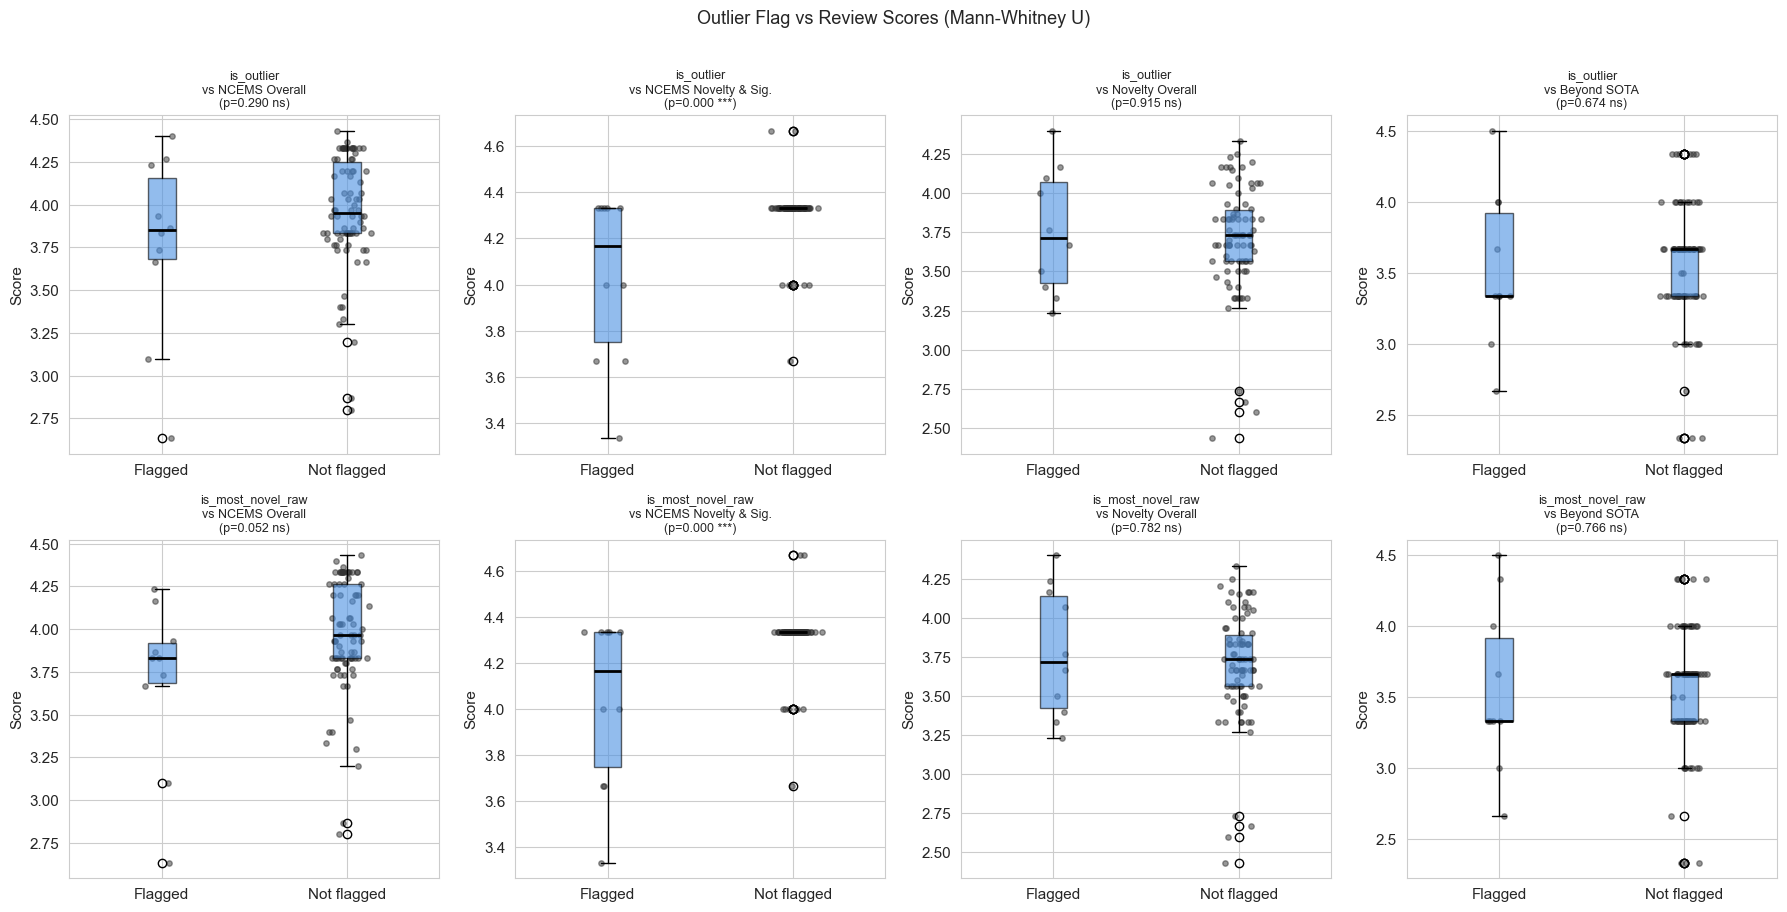

In [16]:
# Box-plots: outlier flags vs key review scores
score_labels = {
    'review_score_mean':      'NCEMS Overall',
    'novelty_and_significance': 'NCEMS Novelty & Sig.',
    'novelty_score_mean':     'Novelty Overall',
    'beyond_state_of_the_art': 'Beyond SOTA',
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax_row, (flag, flag_label) in enumerate([
    ('is_outlier',       'is_outlier'),
    ('is_most_novel_raw', 'is_most_novel_raw'),
]):
    for ax_col, (score, score_label) in enumerate(score_labels.items()):
        ax     = axes[ax_row, ax_col]
        subset = df.dropna(subset=[flag, score])
        groups = {
            True:  subset[subset[flag] == True][score],
            False: subset[subset[flag] == False][score],
        }
        ax.boxplot(
            [groups[True], groups[False]],
            labels=['Flagged', 'Not flagged'],
            patch_artist=True,
            boxprops=dict(facecolor='#4A90E2', alpha=0.6),
            medianprops=dict(color='black', linewidth=2),
        )
        for xi, vals in enumerate([groups[True], groups[False]], 1):
            ax.scatter(np.random.normal(xi, 0.05, size=len(vals)), vals,
                       alpha=0.5, s=15, color='#333')
        if len(groups[True]) >= 2 and len(groups[False]) >= 2:
            _, p = mannwhitneyu(groups[True], groups[False], alternative='two-sided')
            sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            ax.set_title(f'{flag_label}\nvs {score_label}\n(p={p:.3f} {sig})', fontsize=9)
        else:
            ax.set_title(f'{flag_label}\nvs {score_label}', fontsize=9)
        ax.set_ylabel('Score')

plt.suptitle('Outlier Flag vs Review Scores (Mann-Whitney U)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Scatter Plots: Best Metric–Score Pairs

,metric,score,spearman_r,p_value
0,mi_pairwise_mean_dist,relevance_to_emergent_phenomena,-0.6496,0.0
1,mi_nn_dist,relevance_to_emergent_phenomena,-0.5544,0.0
2,pairwise_mean_dist,relevance_to_emergent_phenomena,-0.5479,0.0
3,centroid_dist,relevance_to_emergent_phenomena,-0.5478,0.0
4,nn_dist,relevance_to_emergent_phenomena,-0.5410,0.0
0,centroid_dist,new_theory_concept_method_dataset_or_design,0.5093,0.0


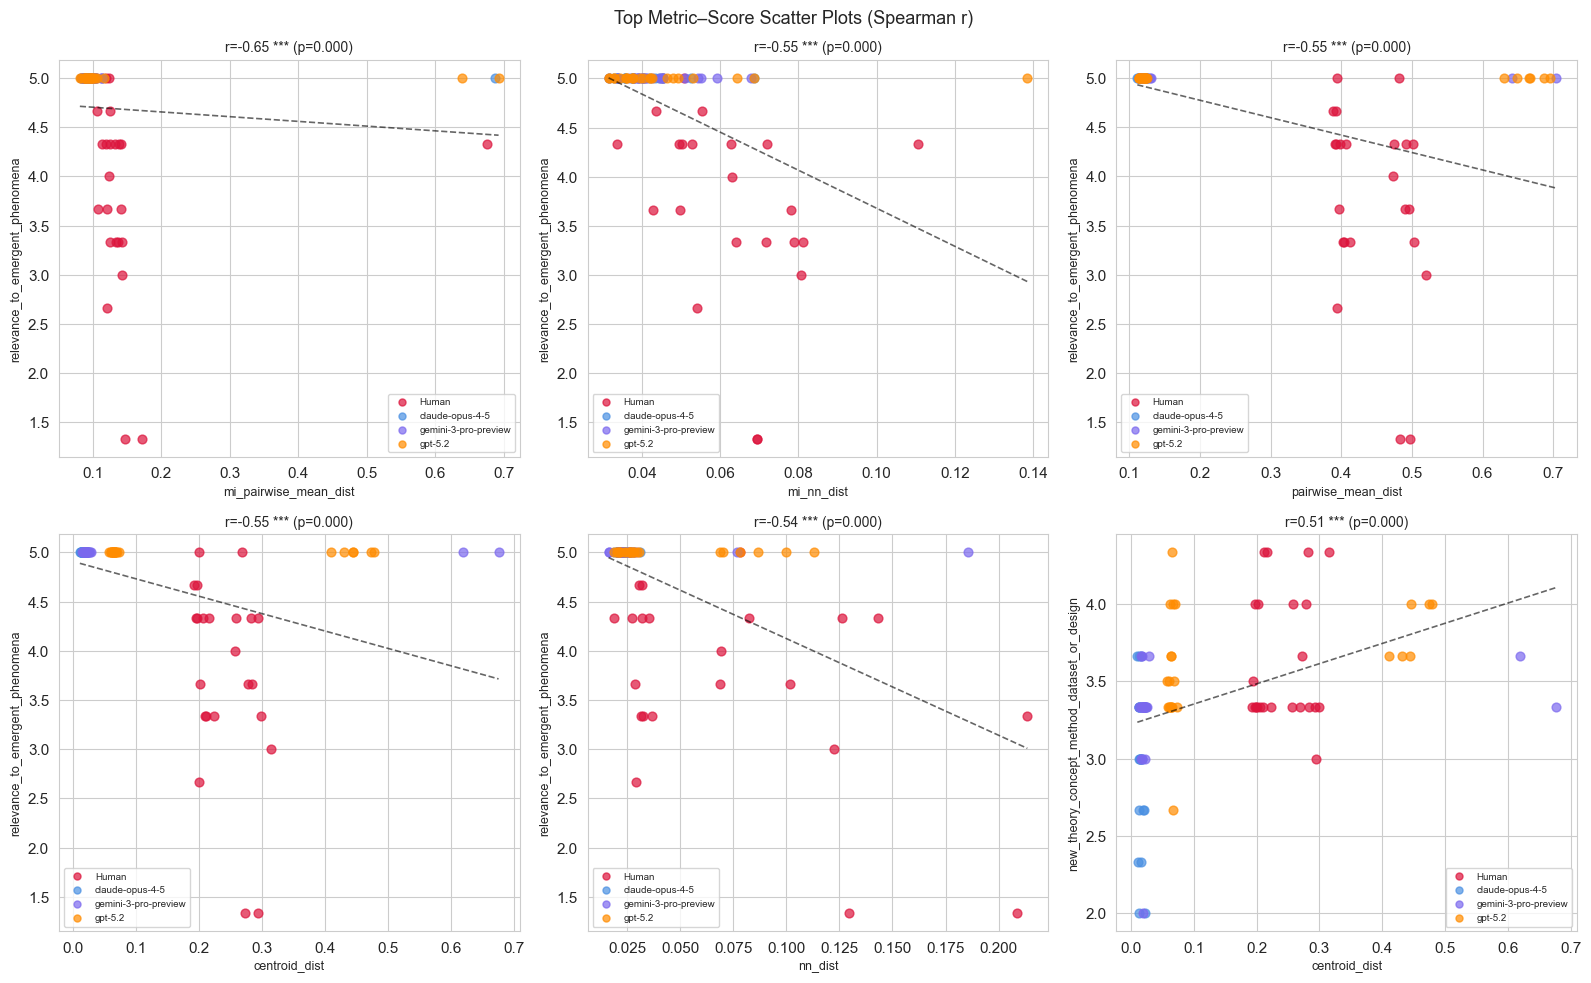

In [17]:
# Pick top 6 metric-score pairs (by |r|) across both correlation tables
all_corrs = (
    pd.concat([
        top_sem_ncems[['metric', 'score', 'spearman_r', 'p_value']],
        top_sem_nov[['metric', 'score', 'spearman_r', 'p_value']],
    ])
    .sort_values('spearman_r', key=abs, ascending=False)
    .drop_duplicates(subset=['metric', 'score'])
)

top_pairs = all_corrs.head(6)
display(top_pairs.round(4))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (_, row) in zip(axes.flat, top_pairs.iterrows()):
    m, s, r, p = row['metric'], row['score'], row['spearman_r'], row['p_value']
    subset = df[['group', m, s]].dropna()
    for grp, grp_df in subset.groupby('group'):
        ax.scatter(grp_df[m], grp_df[s], label=grp,
                   color=colors.get(grp, 'gray'), alpha=0.7, s=40)
    # OLS regression line
    x_vals  = subset[m].values
    y_vals  = subset[s].values
    z       = np.polyfit(x_vals, y_vals, 1)
    x_sorted = np.sort(x_vals)
    ax.plot(x_sorted, np.poly1d(z)(x_sorted), 'k--', linewidth=1.2, alpha=0.6)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    ax.set_xlabel(m, fontsize=9)
    ax.set_ylabel(s, fontsize=9)
    ax.set_title(f'r={r:.2f} {sig} (p={p:.3f})', fontsize=10)
    ax.legend(fontsize=7, markerscale=0.8)

plt.suptitle('Top Metric–Score Scatter Plots (Spearman r)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_scatter_metric_score.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Group-Level Analysis: Human vs AI

Do Human and AI proposals differ in their review scores, and in their metric-score relationships?

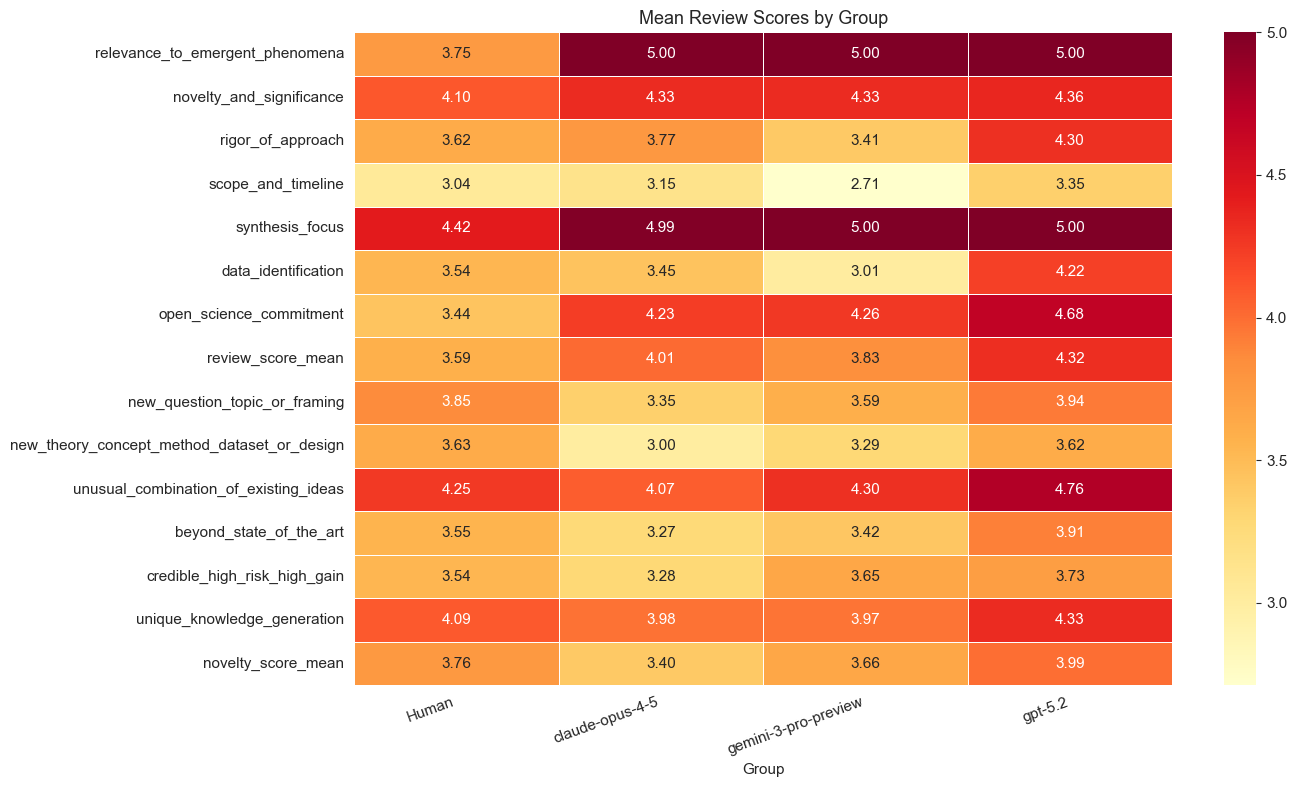

group                                        Human  claude-opus-4-5  \
relevance_to_emergent_phenomena              3.754            5.000   
novelty_and_significance                     4.101            4.333   
rigor_of_approach                            3.623            3.768   
scope_and_timeline                           3.043            3.145   
synthesis_focus                              4.420            4.986   
data_identification                          3.536            3.449   
open_science_commitment                      3.435            4.232   
review_score_mean                            3.586            4.009   
new_question_topic_or_framing                3.855            3.348   
new_theory_concept_method_dataset_or_design  3.630            3.000   
unusual_combination_of_existing_ideas        4.254            4.072   
beyond_state_of_the_art                      3.551            3.268   
credible_high_risk_high_gain                 3.536            3.283   
unique

In [18]:
# Mean scores by group
score_cols_all = NCEMS_SCORES + NOVELTY_SCORES
group_means    = df.groupby('group')[score_cols_all].mean().round(3).T

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(group_means, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Mean Review Scores by Group', fontsize=13)
ax.set_xlabel('Group')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'group_score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(group_means)

AI proposals: 69 | Human proposals: 23


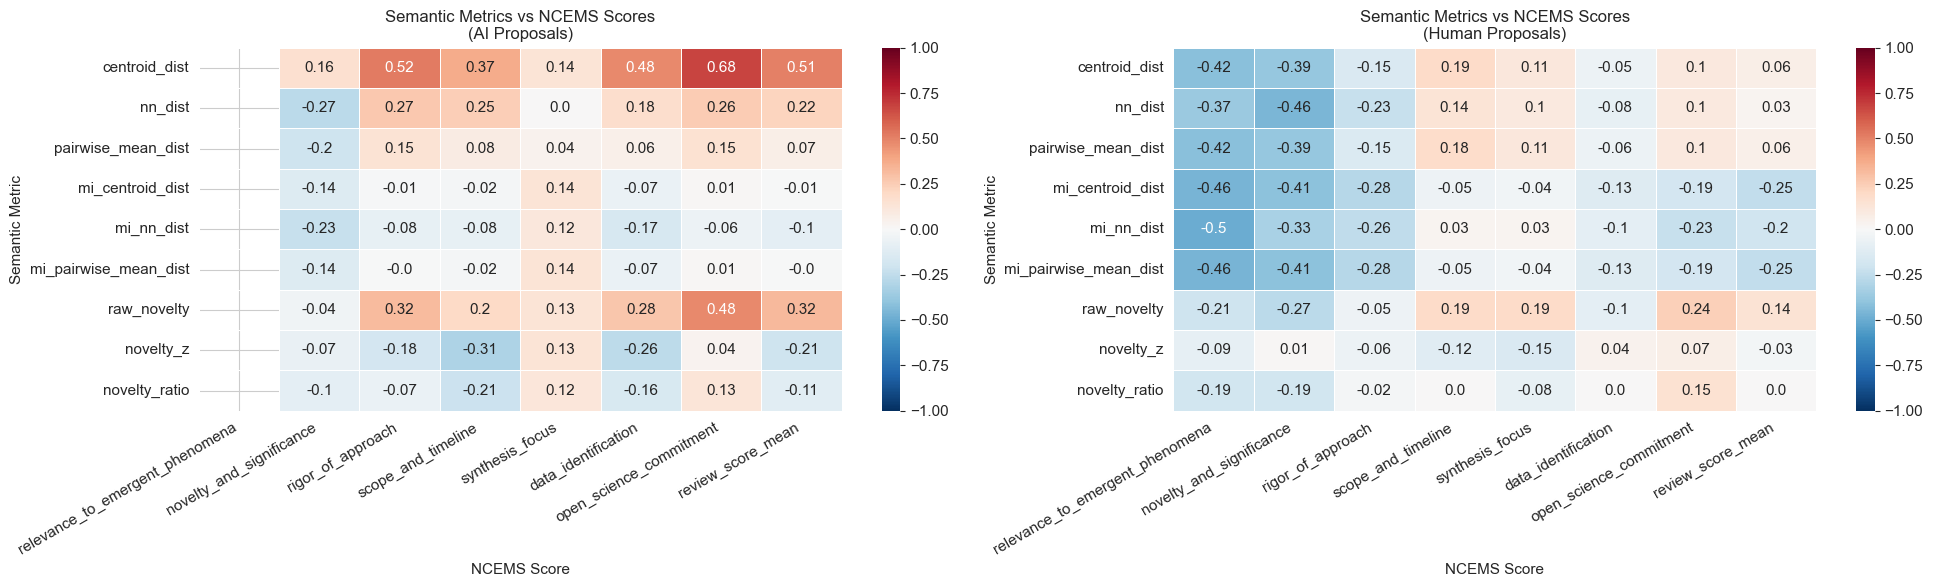

In [19]:
# Human vs AI: separate correlation heatmaps
df_ai    = df[df['is_ai'] == True].copy()
df_human = df[df['is_ai'] == False].copy()

print(f"AI proposals: {len(df_ai)} | Human proposals: {len(df_human)}")

corr_ai_ncems    = compute_corr_matrix(df_ai,    SEMANTIC_METRICS, NCEMS_SCORES)
corr_human_ncems = compute_corr_matrix(df_human, SEMANTIC_METRICS, NCEMS_SCORES)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, corr, label in zip(axes,
                             [corr_ai_ncems, corr_human_ncems],
                             ['AI Proposals', 'Human Proposals']):
    sns.heatmap(corr, annot=corr.round(2), fmt='',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title(f'Semantic Metrics vs NCEMS Scores\n({label})', fontsize=12)
    ax.set_xlabel('NCEMS Score')
    ax.set_ylabel('Semantic Metric')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_ai_vs_human_ncems.png', dpi=150, bbox_inches='tight')
plt.show()

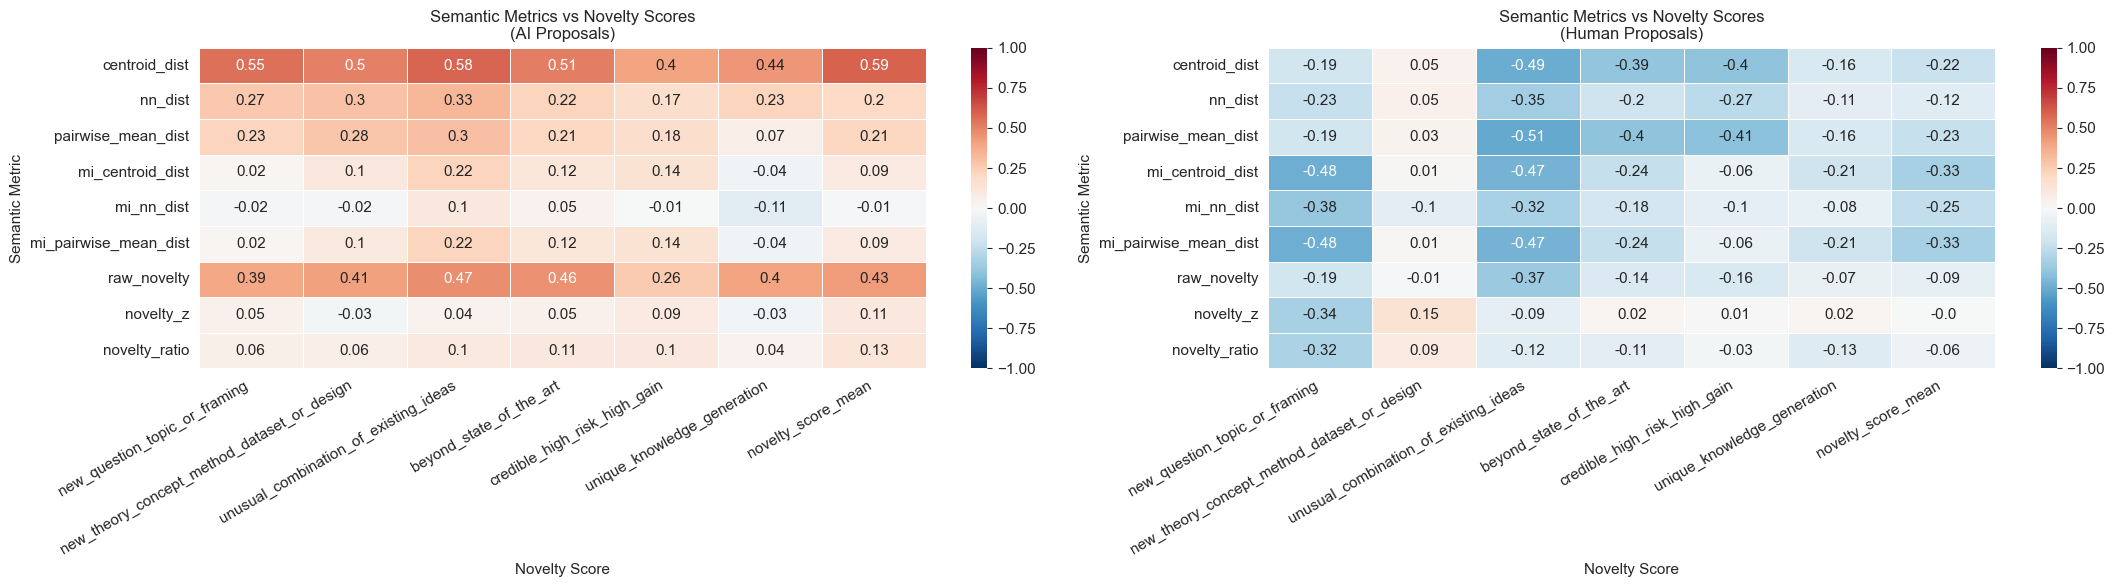

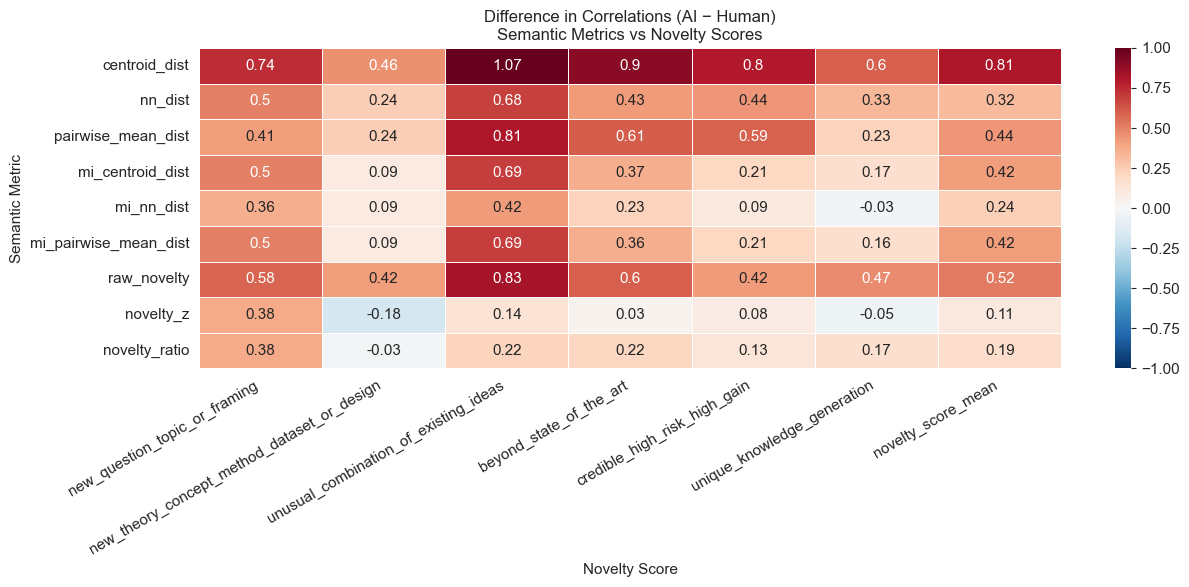

In [23]:
# Human vs AI: semantic metrics vs Novelty scores
corr_ai_nov    = compute_corr_matrix(df_ai,    SEMANTIC_METRICS, NOVELTY_SCORES)
corr_human_nov = compute_corr_matrix(df_human, SEMANTIC_METRICS, NOVELTY_SCORES)

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
for ax, corr, label in zip(axes,
                             [corr_ai_nov, corr_human_nov],
                             ['AI Proposals', 'Human Proposals']):
    sns.heatmap(corr, annot=corr.round(2), fmt='',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title(f'Semantic Metrics vs Novelty Scores\n({label})', fontsize=12)
    ax.set_xlabel('Novelty Score')
    ax.set_ylabel('Semantic Metric')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_ai_vs_human_novelty.png', dpi=150, bbox_inches='tight')
plt.show()

# Difference heatmap: AI minus Human
diff_nov = corr_ai_nov - corr_human_nov
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(diff_nov, annot=diff_nov.round(2), fmt='',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Difference in Correlations (AI − Human)\nSemantic Metrics vs Novelty Scores', fontsize=12)
ax.set_xlabel('Novelty Score')
ax.set_ylabel('Semantic Metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_diff_ai_human_novelty.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Statistics Table

Saved correlation and p-value tables.


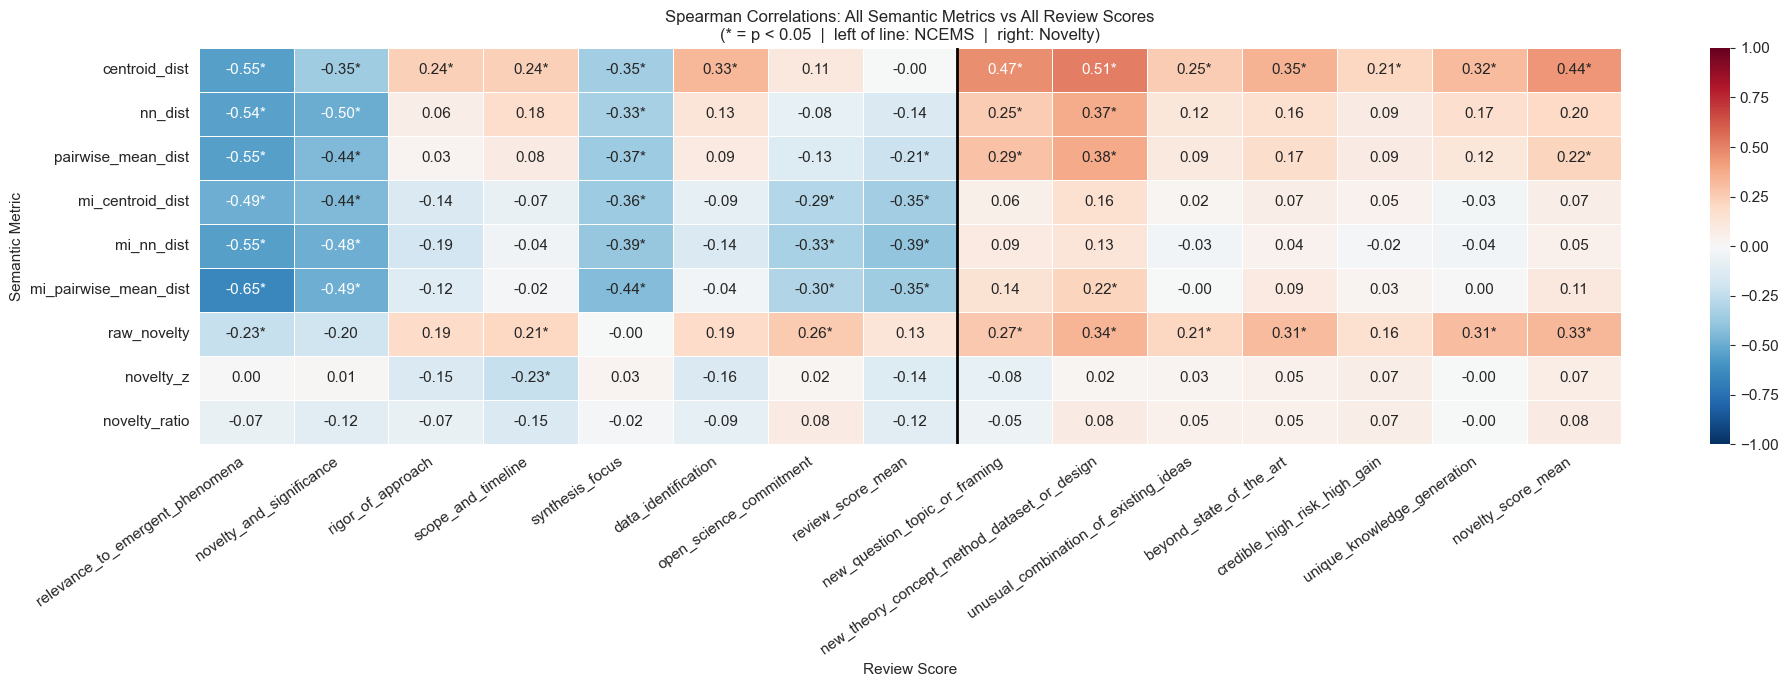

In [20]:
# Full correlation matrix: all semantic metrics vs all review scores
all_metric_score_corr = compute_corr_matrix(df, SEMANTIC_METRICS, NCEMS_SCORES + NOVELTY_SCORES)
all_metric_score_pval = compute_pval_matrix(df, SEMANTIC_METRICS, NCEMS_SCORES + NOVELTY_SCORES)

# Save to CSV
all_metric_score_corr.round(4).to_csv(TABLES_DIR / 'spearman_corr_semantic_all_scores.csv')
all_metric_score_pval.round(6).to_csv(TABLES_DIR / 'spearman_pval_semantic_all_scores.csv')
print("Saved correlation and p-value tables.")

fig, ax = plt.subplots(figsize=(20, 7))
annot_full = all_metric_score_corr.round(2).astype(str)
for m in SEMANTIC_METRICS:
    for s in NCEMS_SCORES + NOVELTY_SCORES:
        r = all_metric_score_corr.loc[m, s]
        p = all_metric_score_pval.loc[m, s]
        annot_full.loc[m, s] = f"{r:.2f}{'*' if p < 0.05 else ''}"

sns.heatmap(
    all_metric_score_corr, annot=annot_full, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.axvline(x=len(NCEMS_SCORES), color='black', linewidth=2)
ax.set_title(
    'Spearman Correlations: All Semantic Metrics vs All Review Scores\n'
    '(* = p < 0.05  |  left of line: NCEMS  |  right: Novelty)', fontsize=12
)
ax.set_xlabel('Review Score')
ax.set_ylabel('Semantic Metric')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_all_semantic_all_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Export the final DataFrame for downstream use
df.to_csv(TABLES_DIR / 'metric_score_df.csv', index=False)
print(f"Exported flat DataFrame with {df.shape[0]} rows and {df.shape[1]} columns to:")
print(f"  {TABLES_DIR / 'metric_score_df.csv'}")

Exported flat DataFrame with 92 rows and 52 columns to:
  ../results/tables/rephrased/minimal/metric-score/metric_score_df.csv
